In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score)
import joblib

In [3]:
df = pd.read_csv("climate_data_2010_2025.csv")

In [4]:
df.head()

,Date,Latitude,Longitude,Max_Temperature,Min_Temperature,Rainfall
0,2010-01-01,8.5,77.5,32.04,22.81,0.0
1,2010-01-01,8.5,78.5,31.11,22.65,0.0
2,2010-01-01,9.5,76.5,31.27,21.50,0.0
3,2010-01-01,9.5,77.5,30.67,21.35,0.0
4,2010-01-01,9.5,78.5,29.44,20.85,0.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1929651 entries, 0 to 1929650
Data columns (total 6 columns):
 #   Column           Dtype  
---  ------           -----  
 0   Date             object 
 1   Latitude         float64
 2   Longitude        float64
 3   Max_Temperature  float64
 4   Min_Temperature  float64
 5   Rainfall         float64
dtypes: float64(5), object(1)
memory usage: 88.3+ MB


In [6]:
df.describe()

,Latitude,Longitude,Max_Temperature,Min_Temperature,Rainfall
count,1.929651e+06,1.929651e+06,1.929651e+06,1.929651e+06,1.929651e+06
mean,2.360236e+01,7.997014e+01,3.095360e+01,1.905098e+01,3.420983e+00
std,6.021268e+00,6.271866e+00,5.929023e+00,6.540145e+00,1.040221e+01
min,8.500000e+00,6.850000e+01,2.015030e+00,-8.820000e+00,0.000000e+00
25%,1.950000e+01,7.550000e+01,2.810998e+01,1.468000e+01,0.000000e+00
50%,2.450000e+01,7.850000e+01,3.134000e+01,2.087535e+01,0.000000e+00
75%,2.750000e+01,8.350000e+01,3.450275e+01,2.415795e+01,1.693357e+00
max,3.650000e+01,9.750000e+01,4.877099e+01,3.320000e+01,8.069304e+02


In [7]:
df.isnull().sum()

Date               0
Latitude           0
Longitude          0
Max_Temperature    0
Min_Temperature    0
Rainfall           0
dtype: int64

In [8]:
df["Date"] = pd.to_datetime(df["Date"])

In [9]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["DayOfYear"] = df["Date"].dt.dayofyear

In [10]:
def get_season(month):
    if month in [12,1,2]:
        return 0
    elif month in [3,4,5]:
        return 1
    elif month in [6,7,8,9]:
        return 2
    else:
        return 3
df["Season"] = df["Month"].apply(get_season)

In [11]:
df["Temp_Difference"] = (
    df["Max_Temperature"]
    -
    df["Min_Temperature"])
df["Avg_Temperature"] = (
    df["Max_Temperature"]
    +
    df["Min_Temperature"])/2
df["Temp_Range"] = (
    df["Max_Temperature"]
    -
    df["Min_Temperature"]
) / (
    df["Max_Temperature"] + 1)

In [12]:
df["Month_sin"] = np.sin(
    2*np.pi*df["Month"]/12)
df["Month_cos"] = np.cos(
    2*np.pi*df["Month"]/12)

In [13]:
df["Day_sin"] = np.sin(
    2*np.pi*df["DayOfYear"]/365)
df["Day_cos"] = np.cos(
    2*np.pi*df["DayOfYear"]/365)

In [14]:
df["Latitude_Square"] = df["Latitude"]**2
df["Longitude_Square"] = df["Longitude"]**2
df["Lat_Long"] = (
    df["Latitude"]*df["Longitude"])

In [15]:
df["Monsoon"] = (
    df["Month"]
    .between(6,9)
    .astype(int))

In [16]:
df["Rainfall_Next_Day"] = (
    df["Rainfall"]
    .shift(-1))

In [17]:
df.dropna(inplace=True)

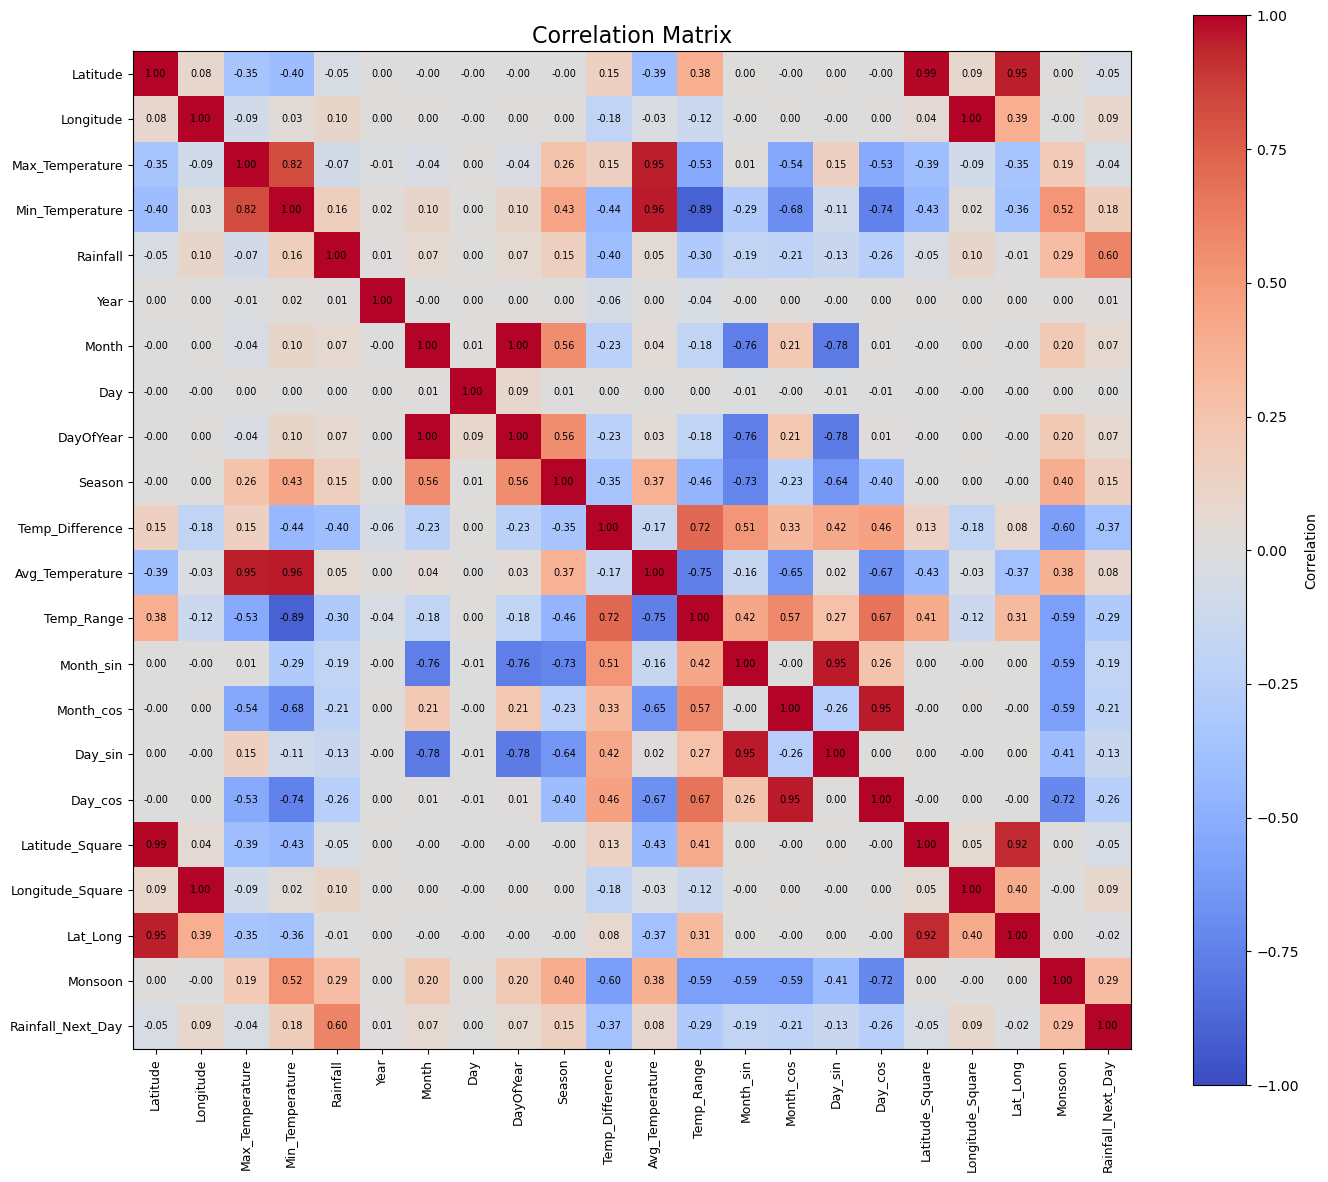

In [18]:
corr = df.select_dtypes(include="number").corr()
fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(np.arange(len(corr.columns)))
ax.set_yticks(np.arange(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90, fontsize=9)
ax.set_yticklabels(corr.columns, fontsize=9)
# Values
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(
            j,
            i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=7,
            color="black")
cbar = plt.colorbar(im)
cbar.set_label("Correlation")
plt.title("Correlation Matrix", fontsize=16)
plt.tight_layout()
plt.show()

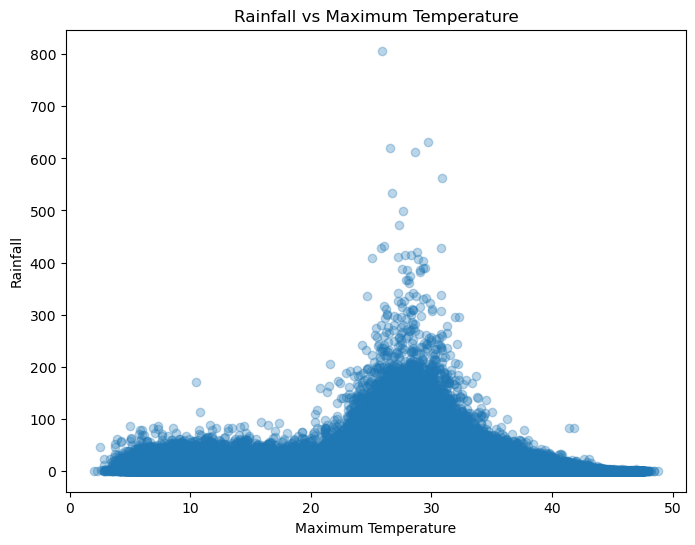

In [19]:
plt.figure(figsize=(8,6))
plt.scatter(
    df["Max_Temperature"],
    df["Rainfall"],
    alpha=0.3)
plt.xlabel("Maximum Temperature")
plt.ylabel("Rainfall")
plt.title("Rainfall vs Maximum Temperature")
plt.show()

In [20]:
print(df.columns.tolist())

['Date', 'Latitude', 'Longitude', 'Max_Temperature', 'Min_Temperature', 'Rainfall', 'Year', 'Month', 'Day', 'DayOfYear', 'Season', 'Temp_Difference', 'Avg_Temperature', 'Temp_Range', 'Month_sin', 'Month_cos', 'Day_sin', 'Day_cos', 'Latitude_Square', 'Longitude_Square', 'Lat_Long', 'Monsoon', 'Rainfall_Next_Day']


In [21]:
features = [
    "Latitude",
    "Longitude",
    "Max_Temperature",
    "Min_Temperature",
    "Year",
    "Month",
    "Day",
    "DayOfYear",
    "Season",
    "Temp_Difference",
    "Avg_Temperature",
    "Temp_Range",
    "Month_sin",
    "Month_cos",
    "Day_sin",
    "Day_cos",
    "Latitude_Square",
    "Longitude_Square",
    "Lat_Long",
    "Monsoon"
]

target = "Rainfall_Next_Day"

In [22]:
X = df[features]
y = df[target]

In [23]:
print(X.shape)
print(y.shape)

(1929650, 20)
(1929650,)


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42)

In [25]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1543720, 20)
(385930, 20)
(1543720,)
(385930,)


In [26]:
from sklearn.ensemble import HistGradientBoostingRegressor
model = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=300,
    max_depth=8,
    min_samples_leaf=20,
    random_state=42)

In [27]:
model.fit(X_train, y_train)

,loss,'squared_error'
,quantile,None
,learning_rate,0.05
,max_iter,300
,max_leaf_nodes,31
,max_depth,8
,min_samples_leaf,20
,l2_regularization,0.0
,max_features,1.0
,max_bins,255
,categorical_features,'from_dtype'


In [28]:
y_pred = model.predict(X_test)
print("R2 Score :", r2_score(y_test, y_pred))
print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score : 0.3845411181582238
MAE : 3.192359466124461
RMSE : 8.324881125455265


In [29]:
from xgboost import XGBRegressor
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1)

In [30]:
model.fit(X_train,y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [31]:
y_pred = model.predict(X_test)

In [32]:
print("R2 Score :", r2_score(y_test, y_pred))
print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score : 0.4552081265897471
MAE : 2.9664798293076777
RMSE : 7.832381434689831


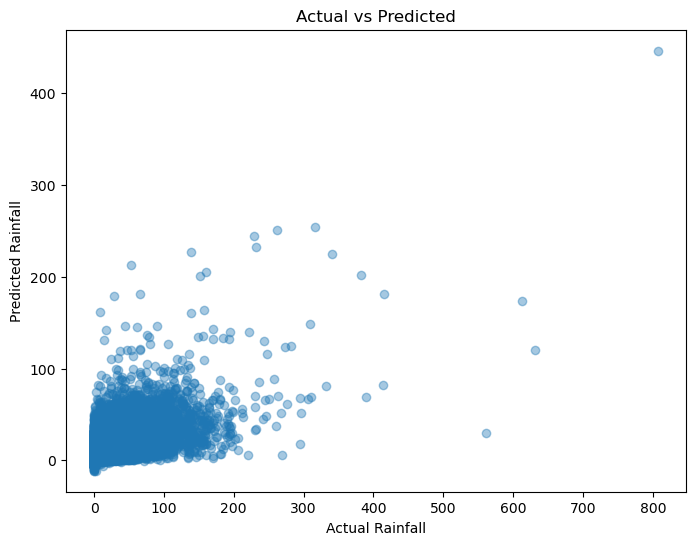

In [33]:
plt.figure(figsize=(8,6))
plt.scatter(
    y_test,
    y_pred,
    alpha=0.4)
plt.xlabel("Actual Rainfall")
plt.ylabel("Predicted Rainfall")
plt.title("Actual vs Predicted")
plt.show()

In [34]:
print(type(model))

<class 'xgboost.sklearn.XGBRegressor'>


In [35]:
joblib.dump(
    model,
    r"C:\Users\HP\ISRO_Project\Models\rainfall_model.pkl")
print("XGBoost model saved successfully!")

XGBoost model saved successfully!


In [36]:
print(type(model))

<class 'xgboost.sklearn.XGBRegressor'>


In [37]:
loaded = joblib.load("../Models/rainfall_model.pkl")
print(type(loaded))

<class 'xgboost.sklearn.XGBRegressor'>


In [38]:
loaded = joblib.load("../Models/rainfall_model.pkl")
print(type(loaded))

<class 'xgboost.sklearn.XGBRegressor'>


In [39]:
import pandas
import sklearn
import xgboost
import joblib
import fastapi
import uvicorn
print("Pandas:", pandas.__version__)
print("Scikit-learn:", sklearn.__version__)
print("XGBoost:", xgboost.__version__)
print("Joblib:", joblib.__version__)
print("FastAPI:", fastapi.__version__)
print("Uvicorn:", uvicorn.__version__)

Pandas: 2.3.3
Scikit-learn: 1.7.2
XGBoost: 3.3.0
Joblib: 1.5.2
FastAPI: 0.138.0
Uvicorn: 0.49.0
